In [1]:
import os
os.chdir("../../../../..")

In [11]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dscribe.kernels import REMatchKernel
from loguru import logger
from umap import UMAP
from rdkit import Chem
from scipy.spatial.distance import cdist
from sklearn.metrics import silhouette_score

from src.non_euclidean import Wasserstein, PersistentHomology
from src.datasets import QM9Dataset

In [3]:
qm9 = QM9Dataset(limit=80_000, descriptors=["soap"])
df = qm9.load()

2026-05-29 10:32:00.911 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-29 10:32:01.515 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=80000, returned_rows=80000, sampling on columns=['num_atoms', 'gap'].
2026-05-29 10:32:01.519 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=80000).
2026-05-29 10:32:01.615 | INFO     | src.features:compute_soap_outputs:395 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-05-29 10:37:09.511 | SUCCESS  | src.datasets:add_soap:1193 - Added SOAP embeddings and matrices.
2026-05-29 10:37:09.597 | INFO     | src.datasets:_add_requested_descriptors:213 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-05-29 10:37:09.798 | INFO     | src.datasets:_load_with_descriptor_filter:857 - QM9 descriptor null-filtering 

In [4]:
def rematch_kernel_dist_matrix(df, metric="linear", alpha=0.1, tol=1e-3):

    soap_matrices = df["soap_matrix"].to_list()

    cleaned = []

    normalized = False
    for i, x in enumerate(soap_matrices):
        x = np.asarray(x, dtype=np.float64)

        # shape check
        if x.ndim != 2:
            raise ValueError(f"SOAP matrix {i} is not 2D: shape={x.shape}")

        # finite check
        if not np.isfinite(x).all():
            raise ValueError(f"Non-finite values in SOAP matrix {i}")

        # ----------------------------
        # Check if already normalized
        # ----------------------------
        norms = np.linalg.norm(x, axis=1)

        already_normalized = np.all(np.abs(norms - 1.0) < tol)

        if already_normalized:
            x_norm = x
            normalized = True
            cleaned = soap_matrices
            logger.info("Descriptor is already normalized")
            if normalized:
                break
        else:
            x_norm = x / (norms[:, None] + 1e-12)
        

        # final sanity check
        if not np.isfinite(x_norm).all():
            raise ValueError(f"NaN/inf after normalization in matrix {i}")

        cleaned.append(x_norm)

    # ----------------------------
    # REMatch kernel
    # ----------------------------
    kernel = REMatchKernel(
        metric=metric,
        alpha=alpha
    )

    print("Computing REMatch kernel matrix...")
    K = kernel.create(cleaned)

    if not np.isfinite(K).all():
        raise ValueError("Kernel matrix contains NaN or inf")

    # ----------------------------
    # Distance conversion
    # ----------------------------
    diag = np.diag(K)
    dist_sq = diag[:, None] + diag[None, :] - 2.0 * K

    dist_sq = np.clip(dist_sq, 0.0, None)
    D = np.sqrt(dist_sq)

    np.fill_diagonal(D, 0.0)
    D = (D + D.T) / 2.0

    return D

In [9]:
def categorize_pure_carbocycle(smiles: str) -> str:
    """
    Parses a SMILES string. 
    Returns '3-ring' or '6-ring' ONLY if the ring is made entirely of Carbon.
    Rejects heterocycles and acyclic structures.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None or "O" in smiles or "N" in smiles:
        return "Other"
    
    ring_info = mol.GetRingInfo().AtomRings()
    if not ring_info:
        return "Acyclic"
        
    for ring in ring_info:
        for atom_idx in ring:
            atom = mol.GetAtomWithIdx(atom_idx)
            if atom.GetAtomicNum() != 6:
                return "Heterocycle"
                
    sizes = set(len(ring) for ring in ring_info)
    if sizes == {3}:
        return "3-ring"
    elif sizes == {6}:
        return "6-ring"
    else:
        return "Mixed/Other"

In [ ]:
def run_ph_vs_rematch_comparison(
    df: pl.DataFrame,
    d_rematch: np.ndarray,
    d_ph_sw: np.ndarray,
    d_ph_b: np.ndarray,
    label_col: str = "ring_category"
) -> None:
    """Evaluates clustering metrics and plots a side-by-side 3-panel UMAP grid."""
    raw_labels = df.get_column(label_col).to_numpy()
    legend_labels = np.where(raw_labels == "3-ring", "Strained (3-Membered)", "Relaxed (6-Membered)")
    unique_classes = np.unique(legend_labels)

    # Added both Sliced Wasserstein and Bottleneck representations
    matrices = {
        "SOAP (REMatch Kernel)": d_rematch,
        "PH (Sliced Wasserstein)": d_ph_sw,
        "PH (Bottleneck Distance)": d_ph_b
    }

    metrics_summary = {}

    for name, dist_matrix in matrices.items():
        sil = silhouette_score(dist_matrix, legend_labels, metric="precomputed")
        
        intra_dists = []
        for cls in unique_classes:
            idx = np.where(legend_labels == cls)[0]
            sub_matrix = dist_matrix[np.ix_(idx, idx)]
            triu_idx = np.triu_indices(len(idx), k=1)
            intra_dists.append(np.mean(sub_matrix[triu_idx]))
        mean_intra = np.mean(intra_dists)

        idx_strained = np.where(legend_labels == "Strained (3-Membered)")[0]
        idx_relaxed = np.where(legend_labels == "Relaxed (6-Membered)")[0]
        inter_matrix = dist_matrix[np.ix_(idx_strained, idx_relaxed)]
        mean_inter = np.mean(inter_matrix)

        separation_ratio = mean_intra / mean_inter
        metrics_summary[name] = {
            "Silhouette": sil, "Intra-Class": mean_intra, "Inter-Class": mean_inter, "Sep-Ratio": separation_ratio
        }

    print("\n" + "="*90)
    print(f"{'Framework / Metric':<35} | {'Intra-Class (↓)':<15} | {'Inter-Class (↑)':<15} | {'Sep Ratio (↓)':<13} | {'Silhouette (↑)':<12}")
    print("-" * 90)
    for name, m in metrics_summary.items():
        print(f"{name:<35} | {m['Intra-Class']:<15.4f} | {m['Inter-Class']:<15.4f} | {m['Sep-Ratio']:<13.4f} | {m['Silhouette']:<12.4f}")
    print("="*90 + "\n")

    # Layout Generation (Expanded to 3 panels)
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(20, 6.5), dpi=300)
    palette = {"Strained (3-Membered)": "#cc5e53", "Relaxed (6-Membered)": "#568bbd"}

    for ax, (name, dist_matrix) in zip(axes, matrices.items()):
        reducer = UMAP(n_neighbors=5, metric="precomputed", random_state=42)
        umap_coords = reducer.fit_transform(dist_matrix)

        sns.scatterplot(
            x=umap_coords[:, 0], y=umap_coords[:, 1],
            hue=legend_labels, palette=palette, s=90, alpha=0.85,
            edgecolors="#2d3436", linewidths=0.8, ax=ax, zorder=10
        )

        ax.set_title(name, fontsize=12, fontweight="bold", pad=12)
        ax.set_xlabel("UMAP Dimension 1", fontsize=9, fontweight="medium")
        ax.set_ylabel("UMAP Dimension 2", fontsize=9, fontweight="medium")
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.get_legend().remove()
        sns.despine(ax=ax)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, title="Descriptor Space Topology Mapping", title_fontsize=10, fontsize=9,
        loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=2,
        frameon=True, facecolor="white", edgecolor="#e2e8f0"
    )

    plt.tight_layout()
    plt.show()


# =============================================================================
# 5. PIPELINE INVOCATION ENGINE (UPDATED FOR TWO TDA METRICS)
# =============================================================================
def run_strain_tda_pipeline(df_base: pl.DataFrame):
    """Executes structural sorting, creates a balanced sub-split, and runs the benchmark."""
    # Step A: Perform RDKit classification
    print("Categorizing rings and filtering pure carbocycles via RDKit...")
    df_classified = df_base.with_columns(
        pl.col("smiles")
        .map_elements(categorize_pure_carbocycle, return_dtype=pl.Utf8)
        .alias("ring_category")
    )

    df_3_rings_all = df_classified.filter(pl.col("ring_category") == "3-ring")
    df_6_rings_all = df_classified.filter(pl.col("ring_category") == "6-ring")

    # Step B: Identify formula overlaps
    counts_3 = df_3_rings_all.group_by("formula").len().rename({"len": "count_3"})
    counts_6 = df_6_rings_all.group_by("formula").len().rename({"len": "count_6"})
    formula_overlap = counts_3.join(counts_6, on="formula", how="inner")

    formula_overlap = formula_overlap.with_columns(
        pl.min_horizontal("count_3", "count_6").alias("max_balanced_size")
    ).sort("max_balanced_size", descending=True)

    if formula_overlap.height == 0:
        raise ValueError("No matching overlapping formulas containing both pure carbocycle types found.")

    best_row = formula_overlap.row(0, named=True)
    best_formula = best_row["formula"]
    max_size = min(best_row["max_balanced_size"], 100) # Balanced sample cap

    print(f"\nTargeting balanced subset for stoichiometry: {best_formula}")
    df_3_sampled = df_3_rings_all.filter(pl.col("formula") == best_formula).sample(n=max_size, seed=42)
    df_6_sampled = df_6_rings_all.filter(pl.col("formula") == best_formula).sample(n=max_size, seed=42)
    df_experiment = pl.concat([df_3_sampled, df_6_sampled])

    # Step C: Distance Matrix Transformations
    d_rematch = rematch_kernel_dist_matrix(df_experiment, metric="linear", alpha=0.1)
    
    # 1. Compute TDA matrix using Sliced Wasserstein
    d_ph_sw = PersistentHomology.distance_matrix(
        df_experiment, 
        descriptor='soap', 
        metric='sliced_wasserstein', 
        max_homology_dim=1,
        homology_dims=(0, 1)
    )

    # 2. Compute TDA matrix using Bottleneck Distance
    d_ph_b = PersistentHomology.distance_matrix(
        df_experiment, 
        descriptor='soap', 
        metric='bottleneck', 
        max_homology_dim=1,
        homology_dims=(0, 1)
    )

    # Step D: Print properties table and plot layout
    run_ph_vs_rematch_comparison(df_experiment, d_rematch, d_ph_sw, d_ph_b, label_col="ring_category")

Categorizing rings and filtering pure carbocycles via RDKit...


2026-05-29 10:40:38.012 | INFO     | __main__:rematch_kernel_dist_matrix:30 - Descriptor is already normalized



Targeting balanced subset for stoichiometry: C9H16
Computing REMatch kernel matrix...


2026-05-29 10:40:38.590 | INFO     | src.non_euclidean:distance_matrix:876 - Computing PH distance matrix | Domain: soap | Metric: sliced_wasserstein | Max Dim: 1
Persistence distances: 100%|██████████| 54/54 [00:05<00:00,  9.15row/s]
2026-05-29 10:40:44.512 | INFO     | src.non_euclidean:distance_matrix:876 - Computing PH distance matrix | Domain: soap | Metric: bottleneck | Max Dim: 1
Persistence distances: 100%|██████████| 54/54 [00:08<00:00,  6.22row/s]
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/User


Framework / Metric                  | Intra-Class (↓) | Inter-Class (↑) | Sep Ratio (↓) | Silhouette (↑)
------------------------------------------------------------------------------------------
SOAP (REMatch Kernel)               | 0.1423          | 0.1542          | 0.9228        | 0.0768      
PH (Sliced Wasserstein)             | 0.6874          | 0.7142          | 0.9624        | 0.0302      
PH (Bottleneck Distance)            | 0.0987          | 0.1005          | 0.9823        | 0.0160      



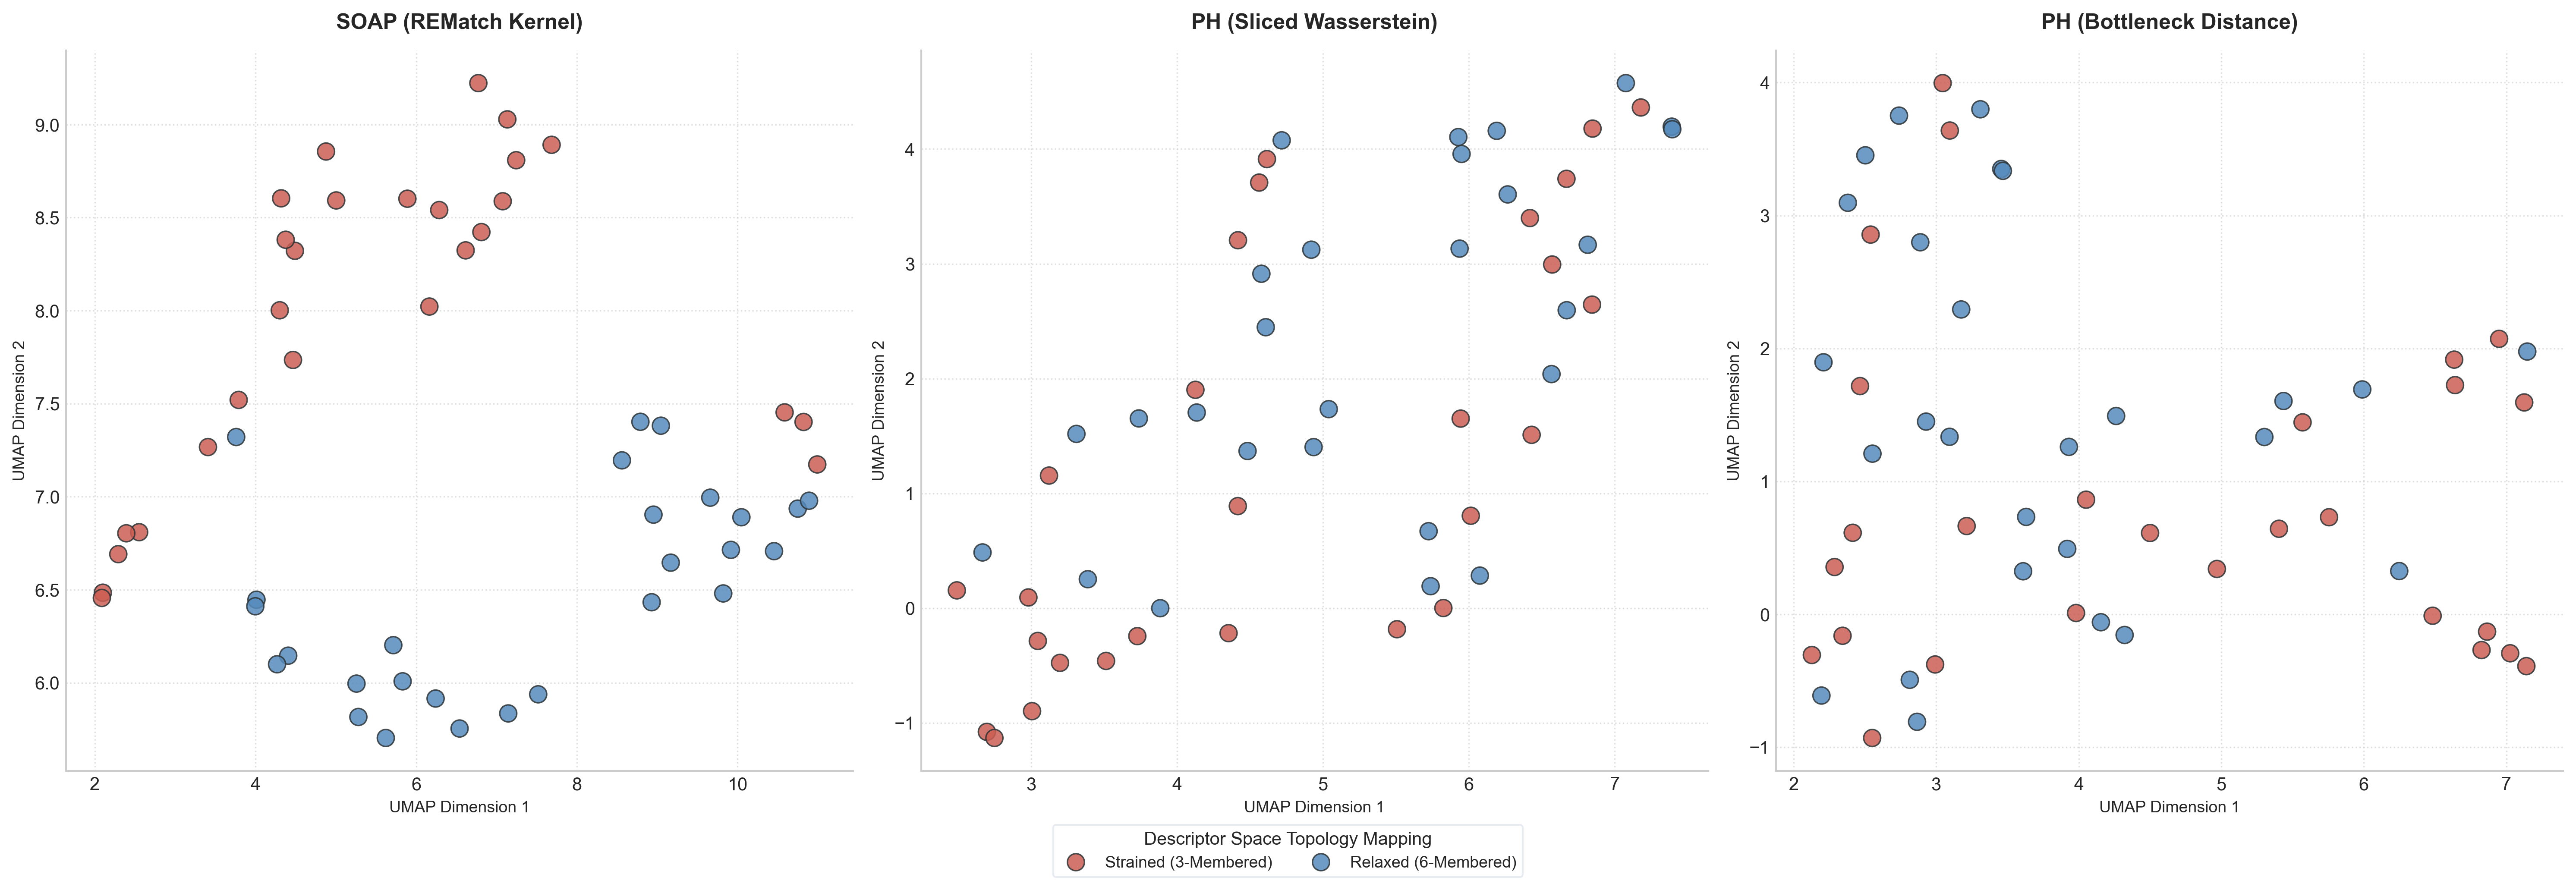

In [15]:
run_strain_tda_pipeline(df)